# Individual Assignment I — Machine Learning Foundations
## name: Lama Moucattash

# Task 1: identifying prediction target

## Prediction target and reasoning
The prediction target is "y" as it is the direct outcome of the campaign, determining whether the costumer successfully subscribed to the term deposit, or not. 

### Why not poutcome? 
The possible values held by this variable are success, failure, or nonexistent. In addition, the word "outcome" is in the name, therefore it can superficially be confused for the target, however after inspecting the dataset we can identify that this is a variable we would have at prediction time. 

In particular, this variable refers to the outcome of previous campaigns. It provides valuable insight on whether the current costumer has subscribed to a previous campaign, and may prove to have high predictive power, but is not the target. This is due to the fact that the goal of this machine learning project is to identify the outcome of the current campaign, not a previous one. 



### Why not duration? 
Duration refers to the length of the call in seconds. It is likely to be highly correlated with the target variable as very short calls often result in no subscription, and a longer call is much more likely to result in a successful subscription. With that said, it is still not what we are trying to predict. Moreover, it is a form of temporal data leakage, as duration is only determined after the call has concluded, which is not available at prediction time. 



# Task 2: Data loading and exploration

In [1]:
import pandas as pd

df = pd.read_csv("bank-additional.csv", sep=";")
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,30,blue-collar,married,basic.9y,no,yes,no,cellular,may,fri,...,2,999,0,nonexistent,-1.8,92.893,-46.2,1.313,5099.1,no
1,39,services,single,high.school,no,no,no,telephone,may,fri,...,4,999,0,nonexistent,1.1,93.994,-36.4,4.855,5191.0,no
2,25,services,married,high.school,no,yes,no,telephone,jun,wed,...,1,999,0,nonexistent,1.4,94.465,-41.8,4.962,5228.1,no
3,38,services,married,basic.9y,no,unknown,unknown,telephone,jun,fri,...,3,999,0,nonexistent,1.4,94.465,-41.8,4.959,5228.1,no
4,47,admin.,married,university.degree,no,yes,no,cellular,nov,mon,...,1,999,0,nonexistent,-0.1,93.200,-42.0,4.191,5195.8,no


In [2]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4119 entries, 0 to 4118
Data columns (total 21 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             4119 non-null   int64  
 1   job             4119 non-null   object 
 2   marital         4119 non-null   object 
 3   education       4119 non-null   object 
 4   default         4119 non-null   object 
 5   housing         4119 non-null   object 
 6   loan            4119 non-null   object 
 7   contact         4119 non-null   object 
 8   month           4119 non-null   object 
 9   day_of_week     4119 non-null   object 
 10  duration        4119 non-null   int64  
 11  campaign        4119 non-null   int64  
 12  pdays           4119 non-null   int64  
 13  previous        4119 non-null   int64  
 14  poutcome        4119 non-null   object 
 15  emp.var.rate    4119 non-null   float64
 16  cons.price.idx  4119 non-null   float64
 17  cons.conf.idx   4119 non-null   f

In [3]:
df['y'].value_counts()
df['y'].value_counts(normalize=True)

y
no     0.890507
yes    0.109493
Name: proportion, dtype: float64

Here, we can see that the dataset is quite imbalanced, which is an issue we should keep in mind since a classifier can achieve deceptively high accuracy by mostly predicting the majority class, while performing poorly on the minority class. Therefore, stratified splitting is required to preserve class proportions across train/validation/test, and (2) consider techniques to address imbalance (e.g., resampling on the training set only) and evaluate performance using metrics othen than accuracy like precision and recall. 

In [4]:
df.describe()

,age,duration,campaign,pdays,previous,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed
count,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000,4119.000000
mean,40.113620,256.788055,2.537266,960.422190,0.190337,0.084972,93.579704,-40.499102,3.621356,5166.481695
std,10.313362,254.703736,2.568159,191.922786,0.541788,1.563114,0.579349,4.594578,1.733591,73.667904
min,18.000000,0.000000,1.000000,0.000000,0.000000,-3.400000,92.201000,-50.800000,0.635000,4963.600000
25%,32.000000,103.000000,1.000000,999.000000,0.000000,-1.800000,93.075000,-42.700000,1.334000,5099.100000
50%,38.000000,181.000000,2.000000,999.000000,0.000000,1.100000,93.749000,-41.800000,4.857000,5191.000000
75%,47.000000,317.000000,3.000000,999.000000,0.000000,1.400000,93.994000,-36.400000,4.961000,5228.100000
max,88.000000,3643.000000,35.000000,999.000000,6.000000,1.400000,94.767000,-26.900000,5.045000,5228.100000


## Exploring missing values

In [5]:
df.isna().sum().sort_values(ascending=False)

age               0
campaign          0
nr.employed       0
euribor3m         0
cons.conf.idx     0
cons.price.idx    0
emp.var.rate      0
poutcome          0
previous          0
pdays             0
duration          0
job               0
day_of_week       0
month             0
contact           0
loan              0
housing           0
default           0
education         0
marital           0
y                 0
dtype: int64

In [6]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
categorical_cols
unknown_counts = {col: (df[col] == "unknown").sum() for col in categorical_cols}
pd.Series(unknown_counts).sort_values(ascending=False)

default        803
education      167
housing        105
loan           105
job             39
marital         11
contact          0
month            0
day_of_week      0
poutcome         0
y                0
dtype: int64

Although there are no explicitly missing values, there are many "unknown" values across the dataset. The variable default contains the highest number of "unknown" entries. The treatment of these cases will be addressed in the missing value management step, but it is important to keep in mind that they may be true missing information, or constitute a meaningful seperate category. 

## Analyzing skewness and distribution

In [7]:
numerical_cols = df.select_dtypes(exclude=["object"]).columns.tolist()
df[numerical_cols].skew().sort_values(ascending=False)

previous          4.022979
campaign          4.003185
duration          3.294781
age               0.715694
cons.conf.idx     0.287309
cons.price.idx   -0.216641
euribor3m        -0.715080
emp.var.rate     -0.727688
nr.employed      -1.075877
pdays            -4.775139
dtype: float64

There exists many skewed variables, most prominently "previous", "campaign", "duration" and "pdays" which we must consider wisely during preprocessing. 

In [8]:
numerical_cols = df.select_dtypes(exclude=["object"]).columns.tolist()

df[numerical_cols].describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
age,40.113620,10.313362,18.000,88.000
duration,256.788055,254.703736,0.000,3643.000
campaign,2.537266,2.568159,1.000,35.000
pdays,960.422190,191.922786,0.000,999.000
previous,0.190337,0.541788,0.000,6.000
emp.var.rate,0.084972,1.563114,-3.400,1.400
cons.price.idx,93.579704,0.579349,92.201,94.767
cons.conf.idx,-40.499102,4.594578,-50.800,-26.900
euribor3m,3.621356,1.733591,0.635,5.045
nr.employed,5166.481695,73.667904,4963.600,5228.100


The numerical variables are measures on substantially different scales. This can affect gradient-based optimization in logistic regression. This therefore calls for feature scaling in later stages. 

## Histogram of duration

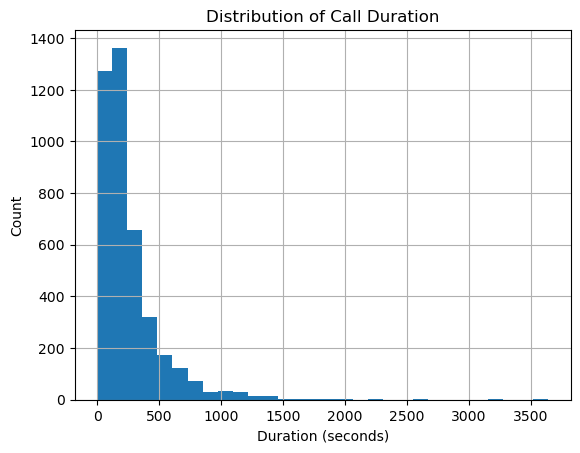

In [9]:
import matplotlib.pyplot as plt
plt.figure()
df["duration"].hist(bins=30)
plt.title("Distribution of Call Duration")
plt.xlabel("Duration (seconds)")
plt.ylabel("Count")
plt.show()

The numerical analysis revealed that "duration" exhibits strong positive skewness. A visualization can help to better understand the source of this skewness. The histogram confirmed that the majority of calls are quite short, with a small number of calls being substantially longer, resulting in a long right tail. This distribution suggests the presence of extreme values. Although skewness alone does not invalidate the feature, it indicates that scaling and potentially transformation may need to be considered during preprocessing.

## Histogram of job distribution 

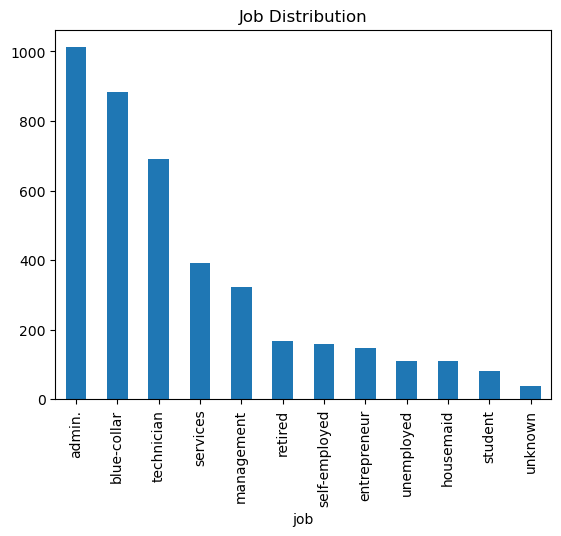

In [10]:
import matplotlib.pyplot as plt
plt.figure()
df["job"].value_counts().plot(kind="bar")
plt.title("Job Distribution")
plt.show()

There is clearly an uneven distribution of occupations in the dataset. This may affect the stability of coefficient estimates when using one-hot encoding in a linear model since rare categories contribute fewer observations. 

## Analyzing pdays distribution

In [11]:
df["pdays"].value_counts().head(15)

pdays
999    3959
3        52
6        42
4        14
7        10
10        8
12        5
5         4
2         4
1         3
9         3
16        2
13        2
18        2
0         2
Name: count, dtype: int64

After observing the sknewness of pdays, analyzing its most frequent values was the next step. We can see that the variable is not a normal continuous variable, and that 999 acts as a categorical flag. It encodes clients not previously contacted. 

## Histogram of pdays excluding 999

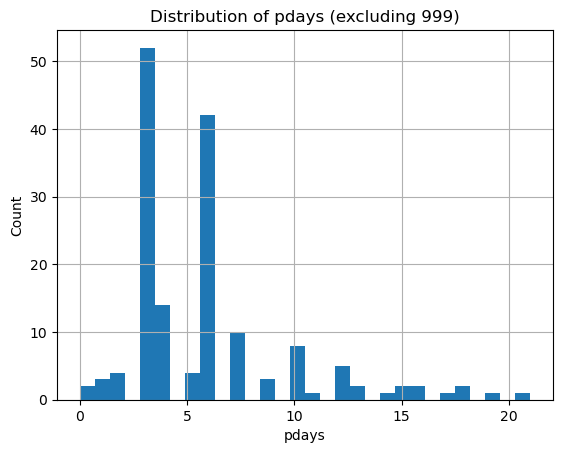

In [12]:
plt.figure()
df[df["pdays"] != 999]["pdays"].hist(bins=30)
plt.title("Distribution of pdays (excluding 999)")
plt.xlabel("pdays")
plt.ylabel("Count")
plt.show()

To better understand the distribution of meaningful `pdays` values, A visualization excluding the 999 value is provided. The resulting distribution shows how the number of days since last contact is distributed among previously contacted clients. This confirms that the extreme skewness observed earlier is primarily driven by the sentinel value 999.

# Task 3: Data Splitting

In [13]:
X = df.drop("y", axis=1)
y = df["y"]

Here we seperate the feature and the target to allow us to stratify on Y later. 

In [14]:
from sklearn.model_selection import train_test_split

# splitting dataset into 70% training set, remaining 30% temporary set.
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y,
    test_size=0.30,
    stratify=y,
    random_state=123
)

I have decided to split the dataset into 70% for training, and the remaining for testing and validation. Since our dataset is quite large, we do not require a training set of greater size, as this is sufficient to estimate model parameters reliably while still having an adequately sized validation and test set. Moreover since the dataset has class imbalance, it is vital to stratify on Y to ensure the proportions of each class in each split is approximately the same.

In [15]:
# split 30% temporary set into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp,
    test_size=0.50,
    stratify=y_temp,
    random_state=123
)
# final sizes
print("Train size:", X_train.shape)
print("Validation size:", X_val.shape)
print("Test size:", X_test.shape)

Train size: (2883, 20)
Validation size: (618, 20)
Test size: (618, 20)


As for the validation and test set, 15% of the dataset for each is effective and sufficient. The justification is that 15% of the dataset is approximately 600 samples each, which is large enough to estimate performance reliably while avoiding high variance in evaluation. 

## Where must splitting occur in the pipeline? 
Splitting must occur after initial exploration, to assess dataset size, stratification needs, and overall patterns in the dataset. 
It must also happen before any preprocessing step that will learn from the data. It must happen befoere imputation, encoding, scaling and feature selection. 

## What types of data leakage would happpen if splitting happens later? 
Several types of data leakage could occur. 
1. statistical leakage: If you split data after computing the mean, median or standard deviation of any variable using the entire dataset. This is because the training set would have indirectly "seen" future data, therefore inflating performance estimates.
2. feature selection leakage: By removing features based on correlation with the target, removing low-variance features or selecting features using the full dataset, the feature decisions are directly influences by the validation and test set, therefore the model gains insight it isn't supposed to have.
3. resampling leakage: If you apply SMOTE or oversampling before splitting, the synthetic samples will be based on validation/test sets too, making them no longer independent.

# Task 4: Managing missing values

From our data exploration, we determined that we do not have any explicit missing values. However, we do have implictly missing values such as "unknown."
To further assess the extent of these missing values, it is of benefit to quantify percentage: 

In [16]:
for col in df.select_dtypes(include='object').columns:
    count = (df[col] == 'unknown').sum()
    if count > 0:
        pct = count / len(df) * 100
        print(f"{col}: {count} unknowns ({pct:.2f}%)")

job: 39 unknowns (0.95%)
marital: 11 unknowns (0.27%)
education: 167 unknowns (4.05%)
default: 803 unknowns (19.50%)
housing: 105 unknowns (2.55%)
loan: 105 unknowns (2.55%)


Dropping rows with "unknown" would discard potentially informative cases and reduce data size. Instead, "unknown" will be retained and treated as its own category during encoding.

Justification: In this context, missingness may not be random as certain clients may withhold information or the bank may fail to record it. Treating "unknown" as a separate category allows the model to learn whether the absence of information itself is predictive, without making unverifiable assumptions required by imputation.
### "Default" having significantly high missing values
default contains a particularly high proportion of "unknown", so retaining it explicitly as a category is preferable to imputation, which would likely bias the feature toward the majority class.

## What should be computed on the training set only?

Any preprocessing step that learns parameters from the data must be fit on the training set only, and then applied to validation/test using the fitted transformation. This prevents information leakage from validation/test into the training process.

In this missing-value strategy:
- **If we imputed values (replacing missing values with the mode/mean),** the imputation values must be computed using the training set only.
- **If we create a missingness indicator** (e.g., `is_unknown_default`), the indicator rule is fixed and does not require fitting; however, it must still be applied consistently across splits.
- **If we keep "unknown" as a category,** there is no imputation parameter to fit. However, the encoder used later like one hot encoding must be fit on the training set only so that category mappings are not influenced by validation/test.
Although the transformation being currently applied are deterministic, applying them after splitting keeps preprocessing aligned with pipeline discipline and prevents mistakes when later steps require training-only fitting.

In [17]:
sentinel_pct = (df["pdays"] == 999).mean() * 100
print(f"Percentage of sentinel values (999) in pdays: {sentinel_pct:.2f}%")

Percentage of sentinel values (999) in pdays: 96.12%


## Handling Sentinel value in pdays
During data exploration we encountered the sentinel value 999 in pdays. It indicated that the customer was never contacted before, not a true numeric measurement.
Since the percentage of costumers not previously contacted is 96.12%, less than 4% of our values contain meaningful numerical values. This raises the concern of whether maintaining these numerical values is necessary, or just introducing unneeded noise. 
Theoretically, we could create another previously_contacted variable, and use imputation for pdays. However in the current case, considering the limited number of numerical data we have, it is much more effective to simply drop pdays entirely, and only keep a binary previously_contacted variable. 


In [18]:
# pdays -> binary indicator + drop pdays (apply to ALL splits)

for X in (X_train, X_val, X_test):
    X["previously_contacted"] = (X["pdays"] != 999).astype(int)
    X.drop(columns=["pdays"], inplace=True)

In [19]:
# Dropping duration to avoid data leakage later on
for X_split in (X_train, X_val, X_test):
    if "duration" in X_split.columns:
        X_split.drop(columns=["duration"], inplace=True)

# Task 5: Encoding categorical variables

In [20]:
before_dim = X_train.shape[1]
print("Before encoding:", before_dim)

Before encoding: 19


In [21]:
# identifying categorical variables
categorical_cols = X_train.select_dtypes(include="object").columns
categorical_cols

Index(['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact',
       'month', 'day_of_week', 'poutcome'],
      dtype='object')

## Classification of variables
**Nominal variables:** 
1. Job
2. Marital
3. Default
4. housing
5. loan
6. contact
7. poutcome
All these variables have no meaningful order

**Ordinal variables:**
1. education
This variable is naturally ordered by educational attainment.

**Cyclical variables:**
1. month
2. days_of_week

In [22]:
# cyclical encoding
import numpy as np

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun',
               'jul', 'aug', 'sep', 'oct', 'nov', 'dec']
day_order = ['mon', 'tue', 'wed', 'thu', 'fri']

month_map = {m: i+1 for i, m in enumerate(month_order)}
day_map = {d: i+1 for i, d in enumerate(day_order)}

for X in (X_train, X_val, X_test):
    month_num = X["month"].map(month_map)
    day_num = X["day_of_week"].map(day_map)

    # Safety check: make sure mapping worked
    if month_num.isna().any():
        bad = X.loc[month_num.isna(), "month"].unique()
        raise ValueError(f"Unmapped month values found: {bad}")

    if day_num.isna().any():
        bad = X.loc[day_num.isna(), "day_of_week"].unique()
        raise ValueError(f"Unmapped day_of_week values found: {bad}")

    X["month_sin"] = np.sin(2 * np.pi * month_num / 12)
    X["month_cos"] = np.cos(2 * np.pi * month_num / 12)
    X["day_sin"] = np.sin(2 * np.pi * day_num / 5)
    X["day_cos"] = np.cos(2 * np.pi * day_num / 5)

# Drop originals
for X in (X_train, X_val, X_test):
    X.drop(columns=["month", "day_of_week"], inplace=True)

Month and days-of-week are cyclical, using sine and cosine encoding will maintain wrap-around relationship while also remaining compatible with linear models. 

In [23]:
# ordinal encoding
from sklearn.preprocessing import OrdinalEncoder

education_order = [[
    'unknown',
    'illiterate', 'basic.4y', 'basic.6y', 'basic.9y',
    'high.school', 'professional.course', 'university.degree'
]]

ordinal_enc = OrdinalEncoder(
    categories=education_order,
    handle_unknown="use_encoded_value",
    unknown_value=-1
)

X_train['education'] = ordinal_enc.fit_transform(X_train[['education']])
X_val['education'] = ordinal_enc.transform(X_val[['education']])
X_test['education'] = ordinal_enc.transform(X_test[['education']])

The variable education possesses a meaningful intrinsic order, reflecting increasing levels of educational attainment (e.g., illiterate → basic education → high school → university degree). Therefore, it is encoded using ordinal encoding rather than one-hot encoding, allowing the model to capture the ordered progression in a numerical form.

The category "unknown" is placed at the lowest ordinal level. This choice reflects the absence of recorded information without implying higher educational level. Assigning it the lowest position will avoid artificially inflating its position inside the educational hierarchy while maintaining interpretability.

The ordinal encoder is fitted only on the training set and subsequently applied to the validation and test sets. This ensures proper pipeline discipline and prevents information leakage from validation or test data into the training process.

In [24]:
import pandas as pd
from sklearn.preprocessing import OneHotEncoder

# nominal encoding (one-hot encoding)

from sklearn.preprocessing import OneHotEncoder
import pandas as pd

nominal_cols = ['job', 'marital', 'default', 'housing', 'loan', 'contact', 'poutcome']

ohe = OneHotEncoder(handle_unknown='ignore', sparse_output=False)
ohe.fit(X_train[nominal_cols])

ohe_train = pd.DataFrame(ohe.transform(X_train[nominal_cols]),
                          columns=ohe.get_feature_names_out(nominal_cols),
                          index=X_train.index)
ohe_val = pd.DataFrame(ohe.transform(X_val[nominal_cols]),
                        columns=ohe.get_feature_names_out(nominal_cols),
                        index=X_val.index)
ohe_test = pd.DataFrame(ohe.transform(X_test[nominal_cols]),
                         columns=ohe.get_feature_names_out(nominal_cols),
                         index=X_test.index)

X_train = X_train.drop(columns=nominal_cols).join(ohe_train)
X_val = X_val.drop(columns=nominal_cols).join(ohe_val)
X_test = X_test.drop(columns=nominal_cols).join(ohe_test)

The remaining categorical variables do not possess an intrinsic ordering and are therefore classified as nominal. To avoid imposing artificial structure, these variables were encoded using One-Hot Encoding.

The encoder was also fitted only on the training set here and subsequently applied to the validation and test sets. This ensures that category mappings are learned only from the training data, thereby avoiding data leakage. The parameter handle_unknown="ignore" was specified to ensure robustness in the event that unseen categories appear in validation or test splits.

After encoding, the original nominal columns were removed and replaced with their one-hot encoded representations, resulting in a fully numerical feature matrix suitable for Logistic Regression.

In [25]:
after_dim = X_train.shape[1]
print("After encoding:", after_dim)
print("Increase in features:", after_dim - before_dim)

After encoding: 44
Increase in features: 25




**Impact on Dimensionality**

One-Hot Encoding increases the dimensionality of the dataset by expanding each nominal variable into multiple binary indicator columns (one per category, or one fewer if a reference category is dropped). As a result, the feature space becomes higher-dimensional, which increases model flexibility but also raises the risk of multicollinearity and overfitting if not handled carefully.

Ordinal encoding, in contrast, preserves dimensionality by mapping categories to a single numerical column. Cyclical encoding expands a single temporal feature into two continuous features (sine and cosine), moderately increasing dimensionality while preserving structural relationships.

**Interpretability of Coefficients**

With One-Hot Encoding, each coefficient represents the log-odds change associated with belonging to a specific category relative to a reference category. This yields clear and interpretable comparisons between groups.

Ordinal encoding produces a single coefficient that represents the change in log-odds for a one-level increase in the ordered variable. This assumes a monotonic relationship between category level and outcome probability.

Cyclical encoding results in coefficients on sine and cosine components, which together model periodic effects. Individual coefficients are less directly interpretable, but the combined effect captures seasonal or cyclical influence.

**Decision Boundaries in Logistic Regression**

Logistic Regression models a linear decision boundary in feature space. Encoding determines the geometry of this space.

- One-Hot Encoding allows the model to assign independent weights to each category, enabling piecewise linear separation across groups.
- Ordinal encoding constrains the model to assume a linear progression across ordered categories.
- Cyclical encoding enables the model to represent smooth periodic decision boundaries, ensuring that adjacent cyclical values (e.g., December and January) are close in feature space.

Thus, encoding directly shapes the types of decision boundaries a linear model can represent.

# Task 6: Feature Scaling

### Features in need of scaling: 
age

campaign

previous

emp.var.rate

cons.price.idx

cons.conf.idx

euribor3m

nr.employed

### Justification for Feature Scaling and its affects

Continuous numerical variables were standardized using StandardScaler. Logistic Regression relies on gradient-based optimization, and features with different scales can lead to poorly conditioned optimization and slower convergence. Additionally, regularization penalties are scale-sensitive; without scaling, features with larger magnitudes can disproportionately influence coefficient estimation. Standardization ensures that features are on a comparable scale, improving numerical stability and allowing coefficients to reflect relative influence more fairly.

Binary indicators and one-hot encoded variables were not scaled. These features are already on a consistent 0–1 scale and represent categorical membership rather than magnitude. Scaling them would reduce interpretability without providing meaningful optimization benefits.

Cyclical features were not scaled because they are already bounded within 1 and -1. The ordinal-encoded education variable was also left unscaled, as its ordered structure is already represented numerically and does not suffer from extreme scale disparities.

### Justifying Chosen Scaling Strategy

For Logistic Regression, standardization using `StandardScaler` is most appropriate. This is because Logistic Regression is typically optimized using gradient-based methods (e.g., gradient descent or quasi-Newton methods such as L-BFGS), which update model coefficients iteratively based on the gradient of the loss function.

When features are on vastly different scales, the loss surface becomes poorly conditioned: the gradients associated with large-scale features can dominate those of smaller-scale features. This can lead to unstable or slow convergence, as the optimization algorithm may take inefficient update steps or require more iterations to reach the minimum. Standardizing the features ensures that they have comparable magnitudes, which improves numerical stability and allows the optimization algorithm to converge more efficiently.

### Fitting only on training 
Since mean and variance are learned parameters, using the full dataset would introduce leakage and give the model access to information from the validation and test set, for that reason we only use training data when computing these statistics. 

In [26]:
from sklearn.preprocessing import StandardScaler

# Identify columns to scale
num_cols = [
    "age", "campaign", "previous",
    "emp.var.rate", "cons.price.idx",
    "cons.conf.idx", "euribor3m", "nr.employed"
]

scaler = StandardScaler()

# Fit on training only
scaler.fit(X_train[num_cols])
 
# Transform all splits
X_train[num_cols] = scaler.transform(X_train[num_cols])
X_val[num_cols] = scaler.transform(X_val[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [27]:
print(X_train[num_cols].mean().round(2))
print(X_train[num_cols].std().round(2))

age               0.0
campaign         -0.0
previous         -0.0
emp.var.rate     -0.0
cons.price.idx   -0.0
cons.conf.idx     0.0
euribor3m        -0.0
nr.employed       0.0
dtype: float64
age               1.0
campaign          1.0
previous          1.0
emp.var.rate      1.0
cons.price.idx    1.0
cons.conf.idx     1.0
euribor3m         1.0
nr.employed       1.0
dtype: float64


# Task 7: Feature selection

## Identify features with very low variance

In [28]:
from sklearn.feature_selection import VarianceThreshold
import pandas as pd

#  threshold for "very low" variance
var_threshold = 0.01  # for standardized continuous features, this flags near-constant features

vt = VarianceThreshold(threshold=var_threshold)
vt.fit(X_train)

support_mask = vt.get_support()
low_var_features = X_train.columns[~support_mask]

# summary table
low_var_summary = pd.DataFrame({
    "feature": low_var_features,
    "variance_train": X_train[low_var_features].var()
}).sort_values("variance_train")

print(f"Low-variance threshold: {var_threshold}")
print(f"Number of low-variance features: {len(low_var_features)}")
low_var_summary

Low-variance threshold: 0.01
Number of low-variance features: 3


,feature,variance_train
default_yes,default_yes,0.000347
marital_unknown,marital_unknown,0.003113
job_unknown,job_unknown,0.009961


### Low-Variance Feature Removal (Training Set Only)

Features with extremely low variance carry little to no information because they take (almost) the same value for nearly all observations. Such features rarely improve predictive performance and can add unnecessary noise, increase dimensionality, and slow optimization in Logistic Regression.

To identify near-constant features, a variance threshold criterion was applied on the **training set only**. Since continuous numerical features were standardized (mean ≈ 0, std ≈ 1), a threshold of **0.01** flags features with variance far below the typical scale, indicating they are effectively constant. The same set of features is to then be removed from validation and test sets to maintain a consistent feature space without introducing data leakage.

In [29]:
# removing low variance features from all sets
low_var_features = low_var_features.tolist()

# Drop from all splits to keep identical columns
X_train = X_train.drop(columns=low_var_features)
X_val   = X_val.drop(columns=low_var_features)
X_test  = X_test.drop(columns=low_var_features)

print("Dropped low-variance features:", low_var_features)
print("New shapes:", X_train.shape, X_val.shape, X_test.shape)

Dropped low-variance features: ['job_unknown', 'marital_unknown', 'default_yes']
New shapes: (2883, 41) (618, 41) (618, 41)


## Identify highly correlated numerical features

In [30]:
import numpy as np
import pandas as pd

# Threshold chosen for high correlation
corr_threshold = 0.80

# Correlation computed on training set only
corr = X_train.corr(numeric_only=True).abs()

# Keep only upper triangle to avoid duplicates/self-correlation
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# All pairs above threshold
high_corr_pairs = (
    upper.stack()
         .reset_index()
         .rename(columns={"level_0": "feature_1", "level_1": "feature_2", 0: "abs_corr"})
)

high_corr_pairs = high_corr_pairs[high_corr_pairs["abs_corr"] >= corr_threshold] \
                               .sort_values("abs_corr", ascending=False)

print(f"High-correlation threshold: {corr_threshold}")
print(f"Number of highly correlated pairs: {len(high_corr_pairs)}")
high_corr_pairs

High-correlation threshold: 0.8
Number of highly correlated pairs: 11


,feature_1,feature_2,abs_corr
777,housing_unknown,loan_unknown,1.000000
810,contact_cellular,contact_telephone,1.000000
742,default_no,default_unknown,0.998899
156,emp.var.rate,euribor3m,0.970183
766,housing_no,housing_yes,0.946787
259,euribor3m,nr.employed,0.943129
354,previously_contacted,poutcome_success,0.931928
793,loan_no,loan_yes,0.909804
157,emp.var.rate,nr.employed,0.898378
817,poutcome_failure,poutcome_nonexistent,0.869038


### Justification for removal and threshold. 

To detect redundancy among numerical features, an absolute Pearson correlation matrix was computed using the **training set only**. Highly correlated predictors can introduce multicollinearity in Logistic Regression, which may inflate coefficient variance, reduce coefficient interpretability, and make the model sensitive to small changes in the data.

A threshold of **|r| ≥ 0.80** was used to define “high correlation.” This cutoff is appropriate to flag near-duplicate information while ensuring we do not aggresively remove features. For each correlated pair exceeding the threshold, we evaluate whether both features provide distinct information or whether one can be removed to simplify the model and improve stability. It is then vital to apply any removal to all sets consistently across training, validation, and test sets to maintain an identical feature space.

In [31]:
# removing redundant features and those not available at prediction time
cols_to_drop = [
    "contact_telephone",
    "housing_no",
    "loan_no",
    "default_unknown",
    "duration"   # remove leakage feature here
]

# Drop only if present (prevents KeyError)
for X in (X_train, X_val, X_test):
    existing = [c for c in cols_to_drop if c in X.columns]
    X.drop(columns=existing, inplace=True)

print("Removed columns:", cols_to_drop)
print("New shapes:", X_train.shape, X_val.shape, X_test.shape)
print("Columns identical across splits?",
      list(X_train.columns) == list(X_val.columns) == list(X_test.columns))

Removed columns: ['contact_telephone', 'housing_no', 'loan_no', 'default_unknown', 'duration']
New shapes: (2883, 37) (618, 37) (618, 37)
Columns identical across splits? True


# Reasoning for the removal of features

Highly correlated dummy variables resulting from one-hot encoding were removed to avoid perfect multicollinearity (dummy variable trap). In binary categorical features (e.g., contact type, housing status, loan status), one category is sufficient to represent the full information. Dropping one category per group preserves informational content while ensuring model identifiability and coefficient stability in Logistic Regression.

Strong correlations among macroeconomic indicators were observed; however, these variables represent related but distinct economic signals. Since they are not deterministically related and Logistic Regression with regularization can mitigate multicollinearity, they were retained.

In addition to removing redundant variables, the feature duration was removed at this stage. Since duration is only known after the call concludes, including it would introduce temporal data leakage. Removing it ensures that the model is trained using only information available at prediction time.

## Why other features with "high correlation" were not removed
Although a correlation threshold of |r| ≥ 0.80 was used to identify highly correlated features, it is bad practice to blindly remove them. For each feature, further analysis is required to determine whether removal is the proper next step, and in some cases the conclusion was to keep some features even though they displayed moderately high correlation. 

In particular, the macroeconomic indicators (emp.var.rate, euribor3m, and nr.employed) exhibit strong correlation because they reflect related economic conditions. However, correlation alone does not imply redundancy. These variables capture distinct aspects of the macroeconomic environment and may provide complementary predictive signal.

Since Logistic Regression with regularization can mitigate the effects of multicollinearity, removing these features solely due to correlation would risk eliminating meaningful information. Therefore, only structurally redundant dummy variables—arising from one-hot encoding of mutually exclusive categories—were removed, while economically meaningful but correlated predictors were retained.

### Why Feature Selection Must Be Performed Using the Training Set Only

Feature selection must be performed using the training set exclusively. If selection criteria like correlation thresholds or variance analysis are computed on the full dataset, structural information from the validation and test sets would influence the feature space used for training. This constitutes train–test leakage.Even if the target variable is not directly used, information about feature relationships from unseen data would be shaping the model. 
### consequences of performing feature selection on the entire dataset
Doing so would lead to an overly optemistic model since the validation and test sets would no longer represent truly unseen data. This is likely to lead to inflated performance estimates that do not generalize well to new, real-world data. 

# Task 8: Addressing class imbalance

In [32]:
# quantifying imbalances
class_counts = y_train.value_counts()
class_proportions = y_train.value_counts(normalize=True)

print("Training Set Class Distribution:")
for label in class_counts.index:
    print(f"{label}: {class_counts[label]} "
          f"({class_proportions[label]*100:.2f}%)")

Training Set Class Distribution:
no: 2567 (89.04%)
yes: 316 (10.96%)


### Class Distribution in the Training Set

As seen previously, the training set exhibits a clear class imbalance, with the majority class (“no”) significantly outweighing the minority class (“yes”). The minority class represents only a small proportion of the observations, indicating that positive subscription outcomes are relatively rare.

This imbalance is a concern because a model could achieve high overall accuracy by predominantly predicting the majority class, while failing to correctly identify minority-class instances. In the context of this task, such an imbalance is definitely a concern as correctly identifying majority and minority classes is likely a priority of the company. Therefore, relying on accuracy would be misleading, and certain strategies must be considered to address the imbalance during training and evaluation.

In [33]:
import pandas as pd


# Random Oversampling (only on training data)


train_df = pd.concat([X_train, y_train.rename("y")], axis=1)

# Assumes binary labels like "yes"/"no"
majority_label = y_train.value_counts().idxmax()
minority_label = y_train.value_counts().idxmin()

majority = train_df[train_df["y"] == majority_label]
minority = train_df[train_df["y"] == minority_label]

# Oversample minority to match majority size
minority_upsampled = minority.sample(
    n=len(majority),
    replace=True,
    random_state=42
)

train_balanced = pd.concat([majority, minority_upsampled]).sample(
    frac=1,
    random_state=42
)

X_train_res = train_balanced.drop(columns=["y"])
y_train_res = train_balanced["y"]

print("Original training distribution:")
print(y_train.value_counts(), "\n")

print("Resampled training distribution:")
print(y_train_res.value_counts())

Original training distribution:
y
no     2567
yes     316
Name: count, dtype: int64 

Resampled training distribution:
y
yes    2567
no     2567
Name: count, dtype: int64


### Why random oversampling was chosen
To address class imbalance, **random oversampling** was applied to the **training set only**. This method balances the dataset by sampling minority-class examples with replacement until the minority and majority classes have equal representation. Oversampling was chosen because it is simple and does not discard any majority-class information (unlike undersampling). It also avoids introducing synthetic data points (as SMOTE/ADASYN would), which can be harder to justify for a baseline Logistic Regression model since it assumes local linearity between nearest neighbors while the minority class may be irregularly distributed.


### Why you should not do resampling before splitting the dataset
If splitting takes place after resampling, you are essentially modifying the entire dataset, part of which will become your validation and test set. Since oversampling replicates minority examples, some of those duplicated examples can end up in the test and validation set, meaning the model has already encounted some of the test and validation examples during training. Even if it’s not the exact same row, it could be a synthetic version generated from the same original point. This is data leakage. 

As with performing feature selection pre-splitting, doing so with resampling would also result in an artificially high performance that performs poorly upon real deployment. 

### The affect of class imbalance on evaluation metrics 
Firstly, accuracy becomes a very misleading evaluation metric, as a model predicting "no"for all cases will achieve very high accuracy of 90% while completely missing the minority class.
Due to this, recall and precision become much more useful.

Recall, which assesses how many actual positives were identified, and precision, which assesses how reliable positive perdictions were, both become much more reliable metrics to evaluate and assess the model and its ability to detect minority-class instances. 

Moreover, based on the particular use case and priorities of the company, the F1 score could also be a very useful metric as it balances recall and precision by penalizing imbalance between them. This becomes especially useful when both false positives and false negatives carry meaningful costs.


# Task 9: Training A Logistic Regression Model

In [34]:
# train logistic regression
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train_res, y_train_res)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [35]:
# predicting on validation set
y_val_pred = lr_model.predict(X_val)

In [36]:
# Accuracy, Precision, Recall + Zero Rule baseline comparison
from sklearn.metrics import accuracy_score, precision_score, recall_score

# Metrics
acc = accuracy_score(y_val, y_val_pred)
prec = precision_score(y_val, y_val_pred, pos_label="yes")
rec = recall_score(y_val, y_val_pred, pos_label="yes")

print("Logistic Regression (Validation)")
print(f"Accuracy : {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall   : {rec:.4f}")

# Zero Rule baseline (always predict majority class from training set)
majority_class = y_train.value_counts().idxmax()
y_val_zero = [majority_class] * len(y_val)

zero_acc = accuracy_score(y_val, y_val_zero)

print("\nZero Rule Baseline (Validation)")
print(f"Accuracy : {zero_acc:.4f}")


Logistic Regression (Validation)
Accuracy : 0.7767
Precision: 0.2697
Recall   : 0.6029

Zero Rule Baseline (Validation)
Accuracy : 0.8900


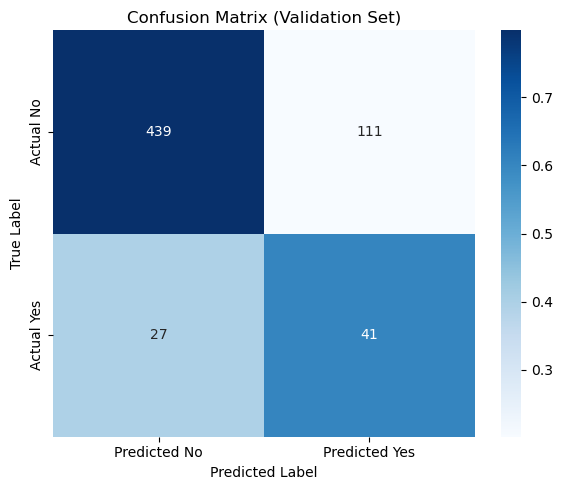

In [37]:
# confusion matrix 

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Compute confusion matrix
cm = confusion_matrix(y_val, y_val_pred, labels=["no", "yes"])

# Normalize for proportions
cm_norm = cm / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm_norm,
    annot=cm,
    fmt="d",
    cmap="Blues",
    xticklabels=["Predicted No", "Predicted Yes"],
    yticklabels=["Actual No", "Actual Yes"]
)

plt.title("Confusion Matrix (Validation Set)")
plt.ylabel("True Label")
plt.xlabel("Predicted Label")
plt.tight_layout()
plt.show()

True Positives (TP): 41  
False Positives (FP): 111  
False Negatives (FN): 27  
True Negatives (TN): 439

In [38]:
# metric summary table
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

# Zero Rule baseline
majority_class = y_train.value_counts().idxmax()
y_val_pred_zero = [majority_class] * len(y_val)

results_df = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score"],
    "Logistic Regression": [
        accuracy_score(y_val, y_val_pred),
        precision_score(y_val, y_val_pred, pos_label="yes"),
        recall_score(y_val, y_val_pred, pos_label="yes"),
        f1_score(y_val, y_val_pred, pos_label="yes")
    ],
    "Zero Rule": [
        accuracy_score(y_val, y_val_pred_zero),
        None,
        None,
        None
    ]
})

results_df

,Metric,Logistic Regression,Zero Rule
0,Accuracy,0.776699,0.889968
1,Precision,0.269737,NaN
2,Recall,0.602941,NaN
3,F1-Score,0.372727,NaN


### Final Model Analysis and Conclusion

The Logistic Regression model behaves as expected given the structure of the dataset and the preprocessing pipeline implemented. Although the model’s overall accuracy of 0.78 is lower than the Zero Rule baseline of 0.89, this result is expected when provided with a highly imbalanced dataset. The Zero Rule achieves high accuracy by always predicting the majority class, but it completely fails to identify minority-class instances, therefore achieving lower accuracy but identifying an appropriate amount of minority-class instances is a worthwhile trade-off. 

In fact, the trained model successfully detects approximately 60% of actual subscribers, demonstrating meaningful recall for the minority class. While this improvement comes at the cost of reduced precision and overall accuracy, it reflects a deliberate trade-off in favor of detecting potential term deposit subscribers rather than defaulting to majority-class predictions.

The preprocessing pipeline including proper handling of missing values, encoding decisions aligned with logistic regression assumptions, appropriate scaling, inteligent feature selection, and careful imbalance treatment resulted in a coherent and logically behaving model.

Overall, the results confirm that the data preparation steps were correctly implemented and that the model’s behavior aligns with theoretical expectations under class imbalance.

In [39]:
# Task 10:  Task ordering 

## Task order and justification

**Task 1: Identifying the Prediction Target**

This must come first because every subsequent decision depends on what is being predicted and what information is available at prediction time.

*Allowed:* Full understanding of dataset description, domain meaning, and definition of the target variable y.

*Not allowed:* Using validation/test performance to redefine the target or adjust its definition.

**Task 2: Data Loading and Exploration**

Exploration comes before splitting to grasp structure, distributions, and potential issues such as imbalance or sentinel values.

*Allowed:* Summary statistics, distribution inspection, class proportions, identification of missing/sentinel values.

*Not allowed:* Making preprocessing decisions based on validation/test-specific patterns like computing imputation values or scaling parameters on full data.

**Task 3: Data Splitting**

Splitting must occur early to enforce strict separation between training and evaluation data.

*Allowed:* Stratification based on y to preserve class proportions.

*Not allowed:* Performing any parameter-learning preprocessing like scaling, encoding or imputation before splitting.

**Task 4: Managing Missing Values**

Missing value handling follows splitting because some strategies require fitting parameters.

*Allowed:* Rule-based transformations, fitting imputers on training only, applying same transformation to validation and test set.

*Not allowed:* Computing imputation statistics using full dataset as it causes train–test leakage

**Task 5: Encoding Categorical Variables**

Encoding must occur before modeling since Logistic Regression requires numeric input.

*Allowed:* Determining encoding scheme conceptually and fitting encoders on training only. You may then apply mapping consistently to validation and test set.

*Not allowed:* Fitting encoders on full data (would leak unseen categories into training representation).

**Task 6: Feature Scaling**

Scaling follows encoding because it operates on numeric representations.

*Allowed:* Fitting scaler on training set only; applying same transformation to validation and test set.

*Not allowed:* Computing scaling parameters (mean/std) using full dataset (distribution leakage).

**Task 7: Feature Selection**

Feature selection comes after encoding and scaling because correlation/variance depend on numeric feature space.

*Allowed:* Computing variance/correlation on training set only; applying selected feature removals consistently across splits.

*Not allowed:* Using full dataset correlations or validation performance to determine feature removal (model-selection leakage).

**Task 8: Addressing Class Imbalance**

Resampling must occur after preprocessing but only on the training set.

*Allowed:* Oversampling or weighting on X_train, y_train only.

*Not allowed:* Resampling before splitting (causes duplicate leakage) or modifying validation/test distributions.

**Task 9: Training Logistic Regression**

Training must be performed only after the full preprocessing pipeline is finalized.

*Allowed:* Training on processed training data and tuning using validation set if explicitly structured.

*Not allowed:* Adjusting preprocessing based on test performance.

**Task 10: Task Ordering Reflection**

This was chosen as the final step to evaluate and reflect on pipeline coherence and leakage prevention. It synthesizes the reasoning behind the ordering and verifies that each transformation respects training-only fitting.

# How changing the order causes data leakage

**Train–test leakage (distribution leakage):**
Happens when you fit scalers/encoders/imputers/feature selection on the full dataset, so training “learns” from test distribution (means, category sets, correlations). This would have happened if dataset was split after feature selection based on variance and redundancy which would have been computed on the whole dataset

**Duplicate leakage (resampling before split):**
If you oversample first before splitting the dataset, duplicated or synthetic points can end up in both train and validation/test, inflating metrics dramatically because the model sees near-identical data during training.

**Temporal leakage:**
Happens when you include features only known after the outcome (e.g., duration), effectively giving the model future information. This would have happened if we removed the feature (performed feature selection) after training the model. 

**Model-selection leakage:**
Happens when you choose preprocessing steps or features based on validation/test performance without a clean tuning protocol therefore indirectly optimizing to the evaluation set.

# Example of incorrect ordering and its consequences

**Incorrect order:** Apply oversampling before splitting into train/validation/test.
What goes wrong: duplicated (or synthetic-neighbor-based) samples can appear across splits, meaning your validation set is no longer truly “unseen.”

**Consequence:** validation accuracy/recall/precision become overly optimistic, because the model is partly being evaluated on patterns it has effectively already seen. In deployment, performance is poor because real future data will not contain any leaked duplicates, so the evaluation no longer reflects reality.